In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
seed = 42
df = sns.load_dataset('tips')
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [3]:
selected_features = ['total_bill', 'size']

#! Later i might generate new feautres (feature engineering)
# df['tip_percentage'] = df['tip'] / df['total_bill'] * 100
# df['bill_per_person'] = df['total_bill'] / df['size']

In [4]:
X = df[selected_features]
y = df['tip']

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

In [61]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_standard = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
assert X_train_standard.shape == X_train.shape, "Standardized X_train shape does not match X_train's shape"
assert X_train.shape[0] == y_train.shape[0], "X train's shape does not match the y train's shape"
assert X_test.shape[0] == y_test.shape[0], "X test's shape does not match the y test's shape"
assert X_train.shape[1] == X.shape[1] == X_test.shape[1], "Features shape does not match in X_train, X_test, and original X"

In [42]:
def ols(X, y):
  ones = np.ones(X.shape[0]).reshape(-1, 1)
  X = np.concat((ones, X), axis=1)
  return np.linalg.inv(X.T @ X) @ X.T @ y


In [43]:
res = ols(X_train_standard, y_train)
res

array([3.08779487, 0.79502729, 0.24866049])

In [63]:
X_design = np.concat((np.ones(X_test_scaled.shape[0]).reshape(-1, 1), X_test_scaled), axis=1)
pred = X_design @ res

<Axes: ylabel='Density'>

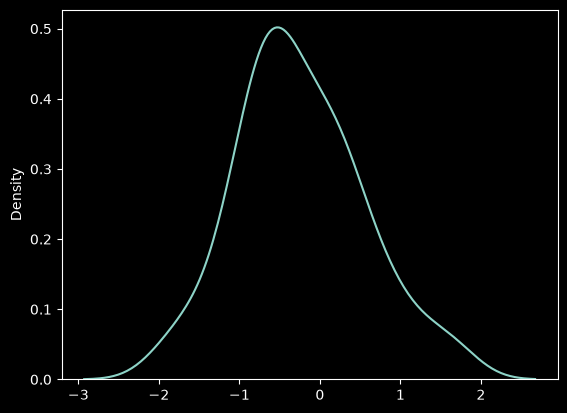

In [72]:
residual = (y_test - pred).to_numpy()

sns.kdeplot(x=residual)


In [73]:
def mse(y, pred):
  return np.mean((y - pred) ** 2)

def rmse(y, pred):
  return np.sqrt(mse(y, pred))

def mae(y, pred):
  return np.mean(np.abs(y - pred))

def r_squared(y, pred):
  mean_y = np.mean(y)
  return 1 - (np.sum((y - pred) ** 2) / np.sum((y - mean_y) ** 2))

def adjusted_r_squared(y, pred, n_features):
  return 1 - (
    ((1 - r_squared(y, pred)) * (y.shape[0] - 1)) / 
    (y.shape[0] - n_features - 1)
  )

In [75]:
mse(y_test, pred), rmse(y_test, pred), mae(y_test, pred), r_squared(y_test, pred), adjusted_r_squared(y_test, pred, X_test.shape[1])

(np.float64(0.6485996190543504),
 np.float64(0.8053568271607005),
 np.float64(0.6639235737596475),
 np.float64(0.4811084097989501),
 np.float64(0.4585479058771653))